In [1]:
import pandas as pd
import re
import json
import argparse
import logging
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
data_source = "omop_mimic_data.xlsx"
mapping_results_file = "omop_mimic_mapping_llama.json"
data = pd.read_excel(data_source, sheet_name=0)
data

,omop,table,des1,des2,label,d1,d2,d3,d4
0,person-person_id,admissions-mimic_id,the person domain contains records that unique...,the admissions table gives information regardi...,0,the person domain contains records that unique...,a unique identifier for each person.,the admissions table gives information regardi...,a unique id for all mimic tables.
1,person-person_id,admissions-hadm_id,the person domain contains records that unique...,the admissions table gives information regardi...,0,the person domain contains records that unique...,a unique identifier for each person.,the admissions table gives information regardi...,hadm_id represents a single patient’s admissio...
2,person-person_id,admissions-admittime,the person domain contains records that unique...,the admissions table gives information regardi...,0,the person domain contains records that unique...,a unique identifier for each person.,the admissions table gives information regardi...,admittime provides the date and time the patie...
3,person-person_id,admissions-dischtime,the person domain contains records that unique...,the admissions table gives information regardi...,0,the person domain contains records that unique...,a unique identifier for each person.,the admissions table gives information regardi...,dischtime provides the date and time the patie...
4,person-person_id,admissions-deathtime,the person domain contains records that unique...,the admissions table gives information regardi...,0,the person domain contains records that unique...,a unique identifier for each person.,the admissions table gives information regardi...,deathtime provides the time of in-hospital dea...
...,...,...,...,...,...,...,...,...,...
64075,provider-gender_source_concept_id,transfers-curr_wardid,the provider table contains a list of uniquely...,transfers are physical locations for patients ...,0,the provider table contains a list of uniquely...,a foreign key to a concept that refers to the ...,transfers are physical locations for patients ...,curr_wardid contains the current ward in which...
64076,provider-gender_source_concept_id,transfers-intime,the provider table contains a list of uniquely...,transfers are physical locations for patients ...,0,the provider table contains a list of uniquely...,a foreign key to a concept that refers to the ...,transfers are physical locations for patients ...,intime provides the date and time the patient ...
64077,provider-gender_source_concept_id,transfers-outtime,the provider table contains a list of uniquely...,transfers are physical locations for patients ...,0,the provider table contains a list of uniquely...,a foreign key to a concept that refers to the ...,transfers are physical locations for patients ...,outtime provides the date and time the patient...
64078,provider-gender_source_concept_id,transfers-los,the provider table contains a list of uniquely...,transfers are physical locations for patients ...,0,the provider table contains a list of uniquely...,a foreign key to a concept that refers to the ...,transfers are physical locations for patients ...,los is the length of stay for the patient for ...


In [3]:
data_positive = data[data["label"] == 1]
data_negative = data[data["label"] == 0]
data_positive

,omop,table,des1,des2,label,d1,d2,d3,d4
207,person-person_id,patients-mimic_id,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,a unique identifier for each person.,patients contains all charted data for all pat...,a unique id for all mimic tables.
441,person-gender_concept_id,patients-gender,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,a foreign key that refers to an identifier in ...,patients contains all charted data for all pat...,gender is the genotypical sex of the patient.
682,person-year_of_birth,patients-dob,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,the year of birth of the person. for data sour...,patients contains all charted data for all pat...,dob is the date of birth of the given patient.
922,person-month_of_birth,patients-dob,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,the month of birth of the person. for data sou...,patients contains all charted data for all pat...,dob is the date of birth of the given patient.
1162,person-day_of_birth,patients-dob,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,the day of the month of birth of the person. f...,patients contains all charted data for all pat...,dob is the date of birth of the given patient.
...,...,...,...,...,...,...,...,...,...
51548,note-note_source_value,noteevents-category,the note table captures unstructured informati...,noteevents contains all notes for patients.;ca...,1,the note table captures unstructured informati...,the source value associated with the origin of...,noteevents contains all notes for patients.,category defines the type of note recorded.
57355,care_site-care_site_name,transfers-curr_wardid,the care_site table contains a list of uniquel...,transfers are physical locations for patients ...,1,the care_site table contains a list of uniquel...,the verbatim description or name of the care s...,transfers are physical locations for patients ...,curr_wardid contains the current ward in which...
61001,provider-provider_id,caregivers-mimic_id,the provider table contains a list of uniquely...,this table provides information regarding care...,1,the provider table contains a list of uniquely...,a unique identifier for each provider.,this table provides information regarding care...,a unique id for all mimic tables.
62919,provider-provider_source_value,caregivers-label,the provider table contains a list of uniquely...,this table provides information regarding care...,1,the provider table contains a list of uniquely...,the identifier used for the provider in the so...,this table provides information regarding care...,label defines the type of caregiver.


In [4]:
data_positive["omop_table_name"] = data_positive["omop"].str.split("-", n=1).str[0]
data_positive["mimic_table_name"] = data_positive["table"].str.split("-", n=1).str[0]
data_positive["omop_column_name"] = data_positive["omop"].str.split("-", n=1).str[1]
data_positive["mimic_column_name"] = data_positive["table"].str.split("-", n=1).str[1]
data_positive

,omop,table,des1,des2,label,d1,d2,d3,d4,omop_table_name,mimic_table_name,omop_column_name,mimic_column_name
207,person-person_id,patients-mimic_id,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,a unique identifier for each person.,patients contains all charted data for all pat...,a unique id for all mimic tables.,person,patients,person_id,mimic_id
441,person-gender_concept_id,patients-gender,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,a foreign key that refers to an identifier in ...,patients contains all charted data for all pat...,gender is the genotypical sex of the patient.,person,patients,gender_concept_id,gender
682,person-year_of_birth,patients-dob,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,the year of birth of the person. for data sour...,patients contains all charted data for all pat...,dob is the date of birth of the given patient.,person,patients,year_of_birth,dob
922,person-month_of_birth,patients-dob,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,the month of birth of the person. for data sou...,patients contains all charted data for all pat...,dob is the date of birth of the given patient.,person,patients,month_of_birth,dob
1162,person-day_of_birth,patients-dob,the person domain contains records that unique...,patients contains all charted data for all pat...,1,the person domain contains records that unique...,the day of the month of birth of the person. f...,patients contains all charted data for all pat...,dob is the date of birth of the given patient.,person,patients,day_of_birth,dob
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51548,note-note_source_value,noteevents-category,the note table captures unstructured informati...,noteevents contains all notes for patients.;ca...,1,the note table captures unstructured informati...,the source value associated with the origin of...,noteevents contains all notes for patients.,category defines the type of note recorded.,note,noteevents,note_source_value,category
57355,care_site-care_site_name,transfers-curr_wardid,the care_site table contains a list of uniquel...,transfers are physical locations for patients ...,1,the care_site table contains a list of uniquel...,the verbatim description or name of the care s...,transfers are physical locations for patients ...,curr_wardid contains the current ward in which...,care_site,transfers,care_site_name,curr_wardid
61001,provider-provider_id,caregivers-mimic_id,the provider table contains a list of uniquely...,this table provides information regarding care...,1,the provider table contains a list of uniquely...,a unique identifier for each provider.,this table provides information regarding care...,a unique id for all mimic tables.,provider,caregivers,provider_id,mimic_id
62919,provider-provider_source_value,caregivers-label,the provider table contains a list of uniquely...,this table provides information regarding care...,1,the provider table contains a list of uniquely...,the identifier used for the provider in the so...,this table provides information regarding care...,label defines the type of caregiver.,provider,caregivers,provider_source_value,label


In [5]:
data_positive.to_csv("data_positive.csv", index=False)

In [6]:
data_positive["omop_table_name"].value_counts()

omop_table_name
drug_exposure           22
observation             20
measurement             16
visit_detail            14
visit_occurrence        11
procedure_occurrence    10
person                   9
condition_occurrence     9
note                     9
specimen                 5
provider                 3
care_site                1
Name: count, dtype: int64

In [7]:

import hashlib


def sha256_of_file(path: Path) -> str:
    if not path.exists():
        return "N/A (file absent)"
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()
 
def load_mapping_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Mapping file not found: {path}")
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data
 
raw_mapping = load_mapping_json(Path(mapping_results_file))
mapping_file_hash = sha256_of_file(Path(mapping_results_file))
 
print("Clés de premier niveau :", list(raw_mapping.keys()))
print("Nombre d'entités mappées :", len(raw_mapping.get("mapping", [])))
print("SHA-256 du fichier de mapping :", mapping_file_hash)
raw_mapping

Clés de premier niveau : ['config', 'mapping']
Nombre d'entités mappées : 21
SHA-256 du fichier de mapping : b9fe1d274a78182557d33030dcc73cbc88c6ae76ea49eccd72e36fd0797b5bea


{'config': {'db_url': None,
  'schema_file': 'mimic_schema.json',
  'dialect': 'postgresql',
  'index_type': 'auto',
  'table_threshold': 0.0,
  'column_threshold': 0.0,
  'top_k': 5},
 'mapping': [{'entity': 'person',
   'matched_table': 'patients',
   'table_confidence': 0.88431,
   'table_rationale': "9/19 attributes have a verified ground-truth match; primary table by vote count is 'patients'.",
   'attributes': [{'name': 'birth_datetime',
     'target_table': 'patients',
     'target_column': 'dob',
     'confidence': 0.8716,
     'rationale': 'Ground-truth verified match (person.birth_datetime -> patients.dob). dob\xa0is the date of birth of the given patient.'},
    {'name': 'care_site_id',
     'target_column': None,
     'confidence': 0.0,
     'rationale': 'No match: no verified correspondence for this attribute was found in the ground-truth OMOP<->MIMIC-III dataset (label=1 rows).'},
    {'name': 'day_of_birth',
     'target_table': 'patients',
     'target_column': 'dob',
 

In [8]:
rows = []
for ent in raw_mapping["mapping"]:
    entity = ent["entity"]
    table = ent["matched_table"]
    table_conf = ent["table_confidence"]
    for a in ent["attributes"]:
        rows.append(dict(
            entity=entity,
            matched_table=table,
            table_confidence=table_conf,
            attribute=a["name"],
            target_column=a["target_column"],
            confidence=a["confidence"],
            rationale=a.get("rationale"),
            source_key=f"{entity}-{a['name']}",
            target_key=(f"{table}-{a['target_column']}" if a["target_column"] else None),
        ))

pred_df = pd.DataFrame(rows)
print(f"Attributs sources dans la sortie du mapping : {len(pred_df)}")
pred_df.head()


Attributs sources dans la sortie du mapping : 267


,entity,matched_table,table_confidence,attribute,target_column,confidence,rationale,source_key,target_key
0,person,patients,0.88431,birth_datetime,dob,0.8716,Ground-truth verified match (person.birth_date...,person-birth_datetime,patients-dob
1,person,patients,0.88431,care_site_id,NaN,0.0000,No match: no verified correspondence for this ...,person-care_site_id,NaN
2,person,patients,0.88431,day_of_birth,dob,0.9179,Ground-truth verified match (person.day_of_bir...,person-day_of_birth,patients-dob
3,person,patients,0.88431,death_datetime,dod,0.9138,Ground-truth verified match (person.death_date...,person-death_datetime,patients-dod
4,person,patients,0.88431,ethnicity_concept_id,NaN,0.0000,No match: no verified correspondence for this ...,person-ethnicity_concept_id,NaN


In [9]:
pred_df.to_csv("pred_df.csv", index=False)

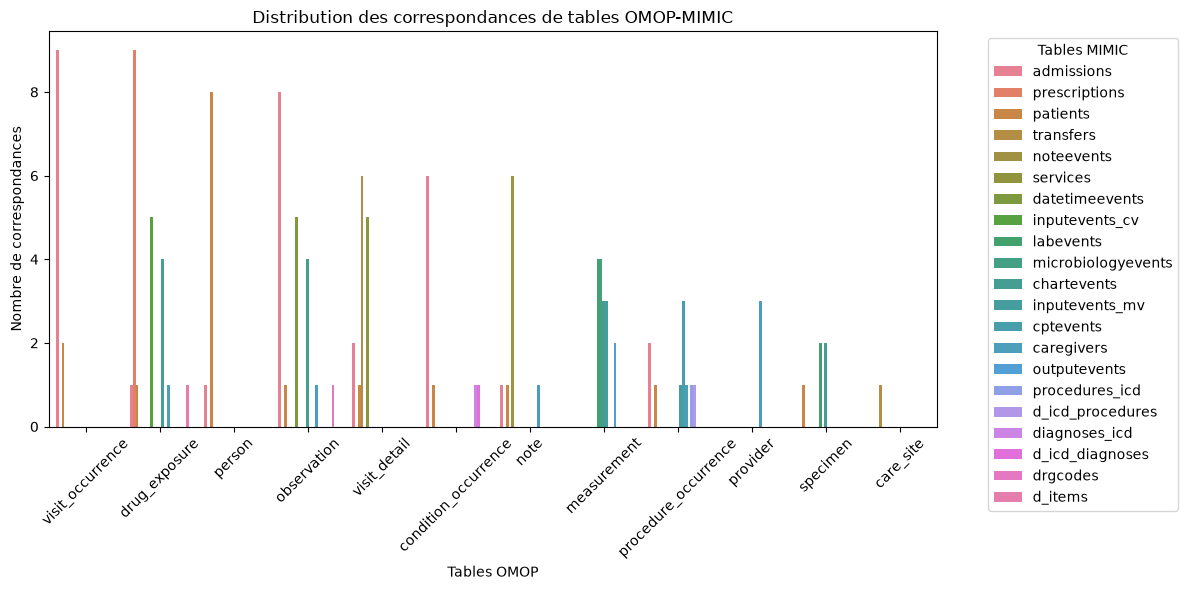

In [10]:
table = data_positive[["omop_table_name", "mimic_table_name"]]
table_counts = table.value_counts().reset_index(name="count")
table_counts = table_counts.rename(columns={0: "count"})
plt.figure(figsize=(12, 6))
plt.title("Distribution des correspondances de tables OMOP-MIMIC")
sns.barplot(data=table_counts, x="omop_table_name", y="count", hue="mimic_table_name")
plt.xlabel("Tables OMOP")
plt.ylabel("Nombre de correspondances")
plt.xticks(rotation=45)
plt.legend(title="Tables MIMIC", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
table

,omop_table_name,mimic_table_name
207,person,patients
441,person,patients
682,person,patients
922,person,patients
1162,person,patients
...,...,...
51548,note,noteevents
57355,care_site,transfers
61001,provider,caregivers
62919,provider,caregivers


In [12]:
table.drop_duplicates(subset=["omop_table_name", "mimic_table_name"], inplace=True)
table

,omop_table_name,mimic_table_name
207,person,patients
3611,person,admissions
4560,visit_occurrence,admissions
5007,visit_occurrence,patients
8869,visit_detail,services
9087,visit_detail,patients
9596,visit_detail,transfers
12480,visit_detail,admissions
13647,specimen,patients
14202,specimen,chartevents


In [13]:
pred_table = pred_df[["entity", "matched_table", "table_confidence"]]

In [14]:
pred_table

,entity,matched_table,table_confidence
0,person,patients,0.88431
1,person,patients,0.88431
2,person,patients,0.88431
3,person,patients,0.88431
4,person,patients,0.88431
...,...,...,...
262,provider,caregivers,0.45350
263,provider,caregivers,0.45350
264,provider,caregivers,0.45350
265,provider,caregivers,0.45350


In [15]:
pred_table.drop_duplicates(subset=["entity", "matched_table"], inplace=True)

In [16]:
pred_table

,entity,matched_table,table_confidence
0,person,patients,0.88431
19,visit_occurrence,admissions,0.87340
36,visit_detail,transfers,0.83540
55,specimen,chartevents,0.47360
70,measurement,labevents,0.81300
90,procedure_occurrence,cptevents,0.76210
104,condition_occurrence,admissions,0.75010
120,death,NaN,0.00000
127,location,NaN,0.00000
135,observation,admissions,0.84490


In [17]:
pred_table[pred_table["matched_table"] == "admissions_items"]


,entity,matched_table,table_confidence


In [18]:
pred_table = pred_table.replace({"matched_table": {"admissions_items": "admissions"}})
pred_table = pred_table.replace({"matched_table": {"diagnoses_icd_items": "diagnoses_icd"}})
pred_table = pred_table.replace({"matched_table": {"procedures_icd_items": "procedures_icd"}})
pred_table = pred_table.replace({"matched_table": {"prescriptions_items": "prescriptions"}})
pred_table = pred_table.replace({"matched_table": {"labevents_items": "labevents"}})
pred_table = pred_table.replace({"matched_table": {"microbiologyevents_items": "microbiologyevents"}})
pred_table = pred_table.replace({"matched_table": {"inputevents_items": "inputevents"}})
pred_table = pred_table.replace({"matched_table": {"outputevents_items": "outputevents"}})
pred_table = pred_table.replace({"matched_table": {"datetimeevents_items": "datetimeevents"}})
pred_table = pred_table.replace({"matched_table": {"chartevents_items": "chartevents"}})
pred_table = pred_table.replace({"matched_table": {"d_icd_diagnoses_items": "d_icd_diagnoses"}})
pred_table = pred_table.replace({"matched_table": {"d_labitems_items": "d_labitems"}})
pred_table

,entity,matched_table,table_confidence
0,person,patients,0.88431
19,visit_occurrence,admissions,0.87340
36,visit_detail,transfers,0.83540
55,specimen,chartevents,0.47360
70,measurement,labevents,0.81300
90,procedure_occurrence,cptevents,0.76210
104,condition_occurrence,admissions,0.75010
120,death,NaN,0.00000
127,location,NaN,0.00000
135,observation,admissions,0.84490


In [19]:
pred_table["label"] = pred_table["table_confidence"].apply(lambda x: 1 if x >= 0.80 else 0)
pred_table

,entity,matched_table,table_confidence,label
0,person,patients,0.88431,1
19,visit_occurrence,admissions,0.87340,1
36,visit_detail,transfers,0.83540,1
55,specimen,chartevents,0.47360,0
70,measurement,labevents,0.81300,1
90,procedure_occurrence,cptevents,0.76210,0
104,condition_occurrence,admissions,0.75010,0
120,death,NaN,0.00000,0
127,location,NaN,0.00000,0
135,observation,admissions,0.84490,1


In [20]:
pred_table[pred_table["label"] == 1].groupby("matched_table").size().reset_index(name="count").sort_values(by="count", ascending=False)
pred_table

,entity,matched_table,table_confidence,label
0,person,patients,0.88431,1
19,visit_occurrence,admissions,0.87340,1
36,visit_detail,transfers,0.83540,1
55,specimen,chartevents,0.47360,0
70,measurement,labevents,0.81300,1
90,procedure_occurrence,cptevents,0.76210,0
104,condition_occurrence,admissions,0.75010,0
120,death,NaN,0.00000,0
127,location,NaN,0.00000,0
135,observation,admissions,0.84490,1


In [21]:
pred_table_positive = pred_table[pred_table["label"] == 1]
pred_table_positive

,entity,matched_table,table_confidence,label
0,person,patients,0.88431,1
19,visit_occurrence,admissions,0.87340,1
36,visit_detail,transfers,0.83540,1
70,measurement,labevents,0.81300,1
135,observation,admissions,0.84490,1


In [22]:
correct_match = 0  # pairs trouvés
false_match = 0  # pairs non trouvés

for _, row in pred_table_positive.iterrows():
    pair = (row["entity"], row["matched_table"])

    if ((table["omop_table_name"] == pair[0]) & 
        (table["mimic_table_name"] == pair[1])).any():
        correct_match += 1
    else:
        false_match += 1

print("Existants :", correct_match)
print("Non existants :", false_match)

Existants : 5
Non existants : 0
